In [2]:
#data_dir = '/tgen_labs/barthel/public_datasets/GLASS-WGS/ecDNA/'
data_dir = '/tgen_labs/barthel/public_datasets/TCGA/ecdna/'


In [3]:
setwd(data_dir)

In [4]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(scales)
library(readr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [5]:
library(readr)
library(dplyr)
library(stringr)
library(janitor)

tcga <- read_csv("aggregated_results_TCGA.csv")
#tcga <- read_csv("aggregated_results.csv")

# Clean column names to snake_case
tcga <- tcga %>% janitor::clean_names()

colnames(tcga)



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


New names:
• `` -> `...1`
Rows: 233 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): Sample name, Feature ID, Classification, Location, Oncogenes, All ...
dbl  (6): ...1, AA amplicon number, Complexity score, Captured interval leng...
lgl  (2): Tissue of origin, Sample type

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "x1"                          "sample_name"                
 [3] "aa_amplicon_number"          "feature_id"                 
 [5] "classification"              "location"                   
 [7] "oncogenes"                   "all_genes"                  
 [9] "complexity_score"            "captured_interval_length"   
[11] "feature_median_copy_number"  "feature_maximum_copy_number"
[13] "filter_flag"                 "reference_version"          
[15] "tissue_of_origin"            "sample_type"                
[17] "feature_bed_file"            "cnv_bed_file"               
[19] "aa_png_file"                 "aa_pdf_file"                
[21] "aa_summary_file"             "run_metadata_json"          
[23] "sample_metadata_json"        "aa_directory"               
[25] "cnvkit_directory"

In [6]:
# Load library
library(readxl)

# Read the Excel file
#data <- read_excel("/scratch/mjehangir/idh_subtypes_ids.xlsx", sheet = 1)

# Save as tab-delimited text file
#write.table(data, "/home/mjehangir/telomere-sv-analysis/data/glioma_status.txt",
          #  sep = "\t", row.names = FALSE, quote = FALSE)



In [7]:
library(dplyr)
library(stringr)

tcga <- tcga %>%
  mutate(
    oncogenes = str_replace_all(oncogenes, "\\[|\\]|'|\"", ""),
    all_genes = str_replace_all(all_genes, "\\[|\\]|'|\"", ""),
    location  = str_replace_all(location, "\\[|\\]|'|\"", "")
  )


In [8]:
head(tcga)

x1,sample_name,aa_amplicon_number,feature_id,classification,location,oncogenes,all_genes,complexity_score,captured_interval_length,⋯,sample_type,feature_bed_file,cnv_bed_file,aa_png_file,aa_pdf_file,aa_summary_file,run_metadata_json,sample_metadata_json,aa_directory,cnvkit_directory
<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
0,TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W,1,8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_amplicon1_BFB_1,BFB,"8:43073406-43102001, 17:20186349-20345399, 17:28018878-28228199, 17:34645518-34853020, 17:34853146-34853664, 17:34873137-34873792, 17:34873831-34886304, 17:34886391-34929124, 17:34931494-34939694, 17:35235900-35316281, 17:35316598-35524499, 17:37832944-38039426, 17:38041762-38048304, 17:38051955-38165634, 17:38237535-38243654","C17orf37, ERBB2, LHX1","AATF, C17orf37, CCDC144C, ERBB2, GGNBP2, GRB7, GSDMA, GSDMB, IKZF3, LHX1, MYO19, ORMDL3, PGAP3, PIGW, PSMD3, TBC1D3G, TBC1D3H, ZNHIT3, ZPBP2",1.2499308,1290151,⋯,NA,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification_bed_files/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_amplicon1_BFB_1_intervals.bed,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/files/G92908.TCGA-BK-A26L-01C-04D-A46W-08.2_CNV_CALLS.bed,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/files/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_amplicon1.png,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/files/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_amplicon1.pdf,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/files/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_summary.txt,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/files/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_run_metadata.json,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/files/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_sample_metadata.json,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_AA_results.tar.gz,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_cnvkit_output.tar.gz
1,TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W,3,8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_amplicon3_BFB_1,BFB,"19:17455257-17545586, 19:17667721-17673941, 19:17802854-17827893, 19:17913701-17940287, 19:18066926-18122519",,"ARRDC2, BST2, FAM125A, INSL3, PLVAP",2.2913704,203767,⋯,NA,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification_bed_files/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_amplicon3_BFB_1_intervals.bed,AA_outputs/TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W/8d21d466-362a-4252-81a9-fedfbeb6da15__ad777252-7eef-4503-8758-dd6109512a09_classification/files/G92908.TCGA-BK-A26L-01C-04D-A46W-08.2_CNV

In [9]:
tcga_subset <- tcga %>%
  select(sample_name, location, classification, oncogenes, all_genes, complexity_score, captured_interval_length)

# peek at it
head(tcga_subset)

sample_name,location,classification,oncogenes,all_genes,complexity_score,captured_interval_length
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W,"8:43073406-43102001, 17:20186349-20345399, 17:28018878-28228199, 17:34645518-34853020, 17:34853146-34853664, 17:34873137-34873792, 17:34873831-34886304, 17:34886391-34929124, 17:34931494-34939694, 17:35235900-35316281, 17:35316598-35524499, 17:37832944-38039426, 17:38041762-38048304, 17:38051955-38165634, 17:38237535-38243654",BFB,"C17orf37, ERBB2, LHX1","AATF, C17orf37, CCDC144C, ERBB2, GGNBP2, GRB7, GSDMA, GSDMB, IKZF3, LHX1, MYO19, ORMDL3, PGAP3, PIGW, PSMD3, TBC1D3G, TBC1D3H, ZNHIT3, ZPBP2",1.2499308,1290151
TCGA-BK-A26L-01C-04D-A46W-08_MN_10A-01D-A46W,"19:17455257-17545586, 19:17667721-17673941, 19:17802854-17827893, 19:17913701-17940287, 19:18066926-18122519",BFB,,"ARRDC2, BST2, FAM125A, INSL3, PLVAP",2.2913704,203767
TCGA-CQ-6225-01A-11D-A32X-10_MN_10A-01D-A32X,2:189203406-189466418,BFB,,,0.7169334,263012
TCGA-CQ-6225-01A-11D-A32X-10_MN_10A-01D-A32X,4:41824999-42611117,Linear amplification,,"BEND4, DCAF4L1, SHISA3, SLC30A9, TMEM33",0.3062158,786118
TCGA-CQ-6225-01A-11D-A32X-10_MN_10A-01D-A32X,4:43398243-43616934,Linear amplification,,,0.3602794,218691
TCGA-CQ-6225-01A-11D-A32X-10_MN_10A-01D-A32X,"8:37433000-37526455, 8:37865227-38561001",Linear amplification,"DDHD2, FGFR1, LSM1, WHSC1L1","ASH2L, BAG4, C8orf86, DDHD2, EIF4EBP1, FGFR1, LETM2, LSM1, PPAPDC1B, STAR, WHSC1L1",0.6700835,789229


In [10]:
nrow(tcga_subset)

[1] 233

In [11]:
# filter only ecDNA entries
tcga_ecDNA <- tcga %>%
  filter(classification == "ecDNA") %>%
  select(sample_name, location, classification, oncogenes, all_genes)

# check result
head(tcga_ecDNA)


sample_name,location,classification,oncogenes,all_genes
<chr>,<chr>,<chr>,<chr>,<chr>
TCGA-06-0128-01A-01D-0572-09_MN_10A-01D-0572,12:58074283-58629028,ecDNA,"AGAP2, CDK4","AGAP2, AVIL, CDK4, CTDSP2, CYP27B1, FAM119B, MARCH9, METTL1, OS9, TSFM, TSPAN31, XRCC6BP1"
TCGA-06-0210-01A-01D-1491-08_MN_10A-01D-1491,4:54365113-55629857,ecDNA,"CHIC2, KIT, PDGFRA","CHIC2, GSX2, KIT, LNX1, PDGFRA, RPL21P44"
TCGA-06-0210-01A-01D-1491-08_MN_10A-01D-1491,1:203277967-204857658,ecDNA,MDM4,"ATP2B4, C1orf157, ETNK2, FMOD, GOLT1A, KISS1, LAX1, LRRN2, MDM4, NFASC, OPTC, PIK3C2B, PLEKHA6, PPP1R15B, PRELP, REN, SNORA77, SNRPE, SOX13, ZBED6, ZC3H11A"
TCGA-06-0210-01A-01D-1491-08_MN_10A-01D-1491,"13:103598980-103736400, 13:112691700-112730840, 2:4967279-5014743, 2:5233210-5236056, 2:5240889-5241464, 2:5246496-5380351",ecDNA,,"SLC10A2, SOX1"
TCGA-CS-6665-01A-11D-1893-08_MN_10A-01D-1893,18:76330971-76921022,ecDNA,,"ATP9B, SALL3"
TCGA-38-4630-01A-01D-2364-08_MN_11A-01D-2364,11:65207761-65373993,ecDNA,MALAT1,"EHBP1L1, FAM89B, KCNK7, LTBP3, MALAT1, SCYL1, SSSCA1"


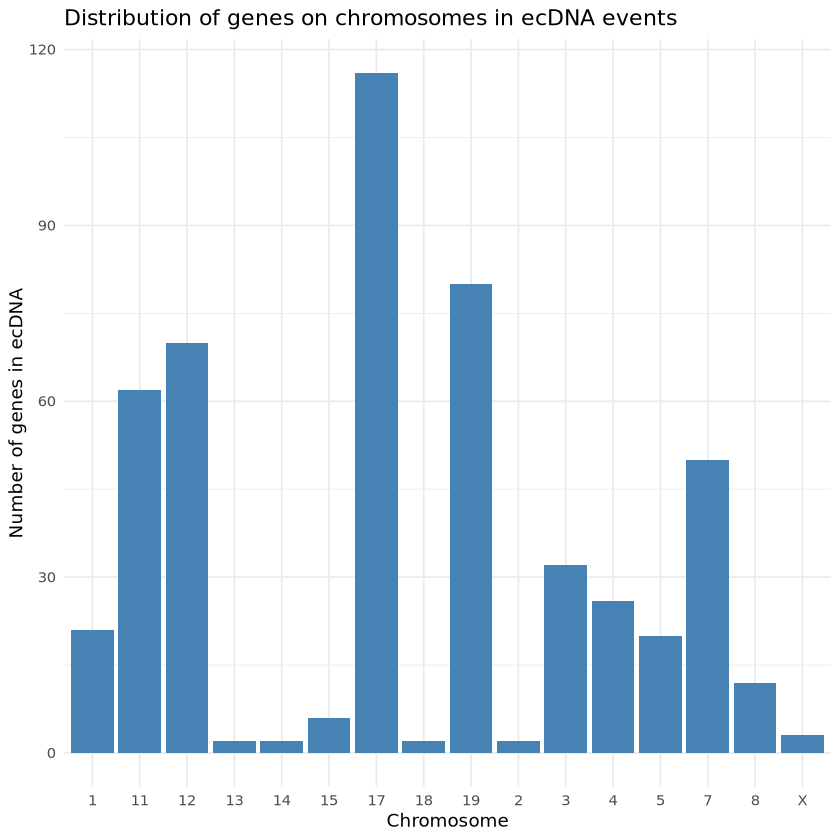

In [12]:

# ---------------------------
tcga_ecDNA <- tcga_ecDNA %>%
  mutate(chromosome = str_extract(location, "^[^:]+"))

# ---------------------------
# 5. Clean and split gene columns
# ---------------------------
tcga_ecDNA <- tcga_ecDNA %>%
  # remove brackets and quotes from all_genes
  mutate(all_genes_clean = str_replace_all(all_genes, "\\[|\\]|'|\"", ""),
         # split into list of genes
         all_genes_list = str_split(all_genes_clean, ",\\s*")) %>%
  # expand so each gene is a separate row
  unnest(all_genes_list)

# ---------------------------
# 6. Count genes per chromosome
# ---------------------------
gene_counts <- tcga_ecDNA %>%
  group_by(chromosome) %>%
  summarise(num_genes = n()) %>%
  arrange(factor(chromosome, levels = c(1:22, "X", "Y"))) # optional: order chromosomes

# ---------------------------
# 7. Plot genes per chromosome
# ---------------------------
ggplot(gene_counts, aes(x = chromosome, y = num_genes)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  theme_minimal() +
  xlab("Chromosome") +
  ylab("Number of genes in ecDNA") +
  ggtitle("Distribution of genes on chromosomes in ecDNA events")

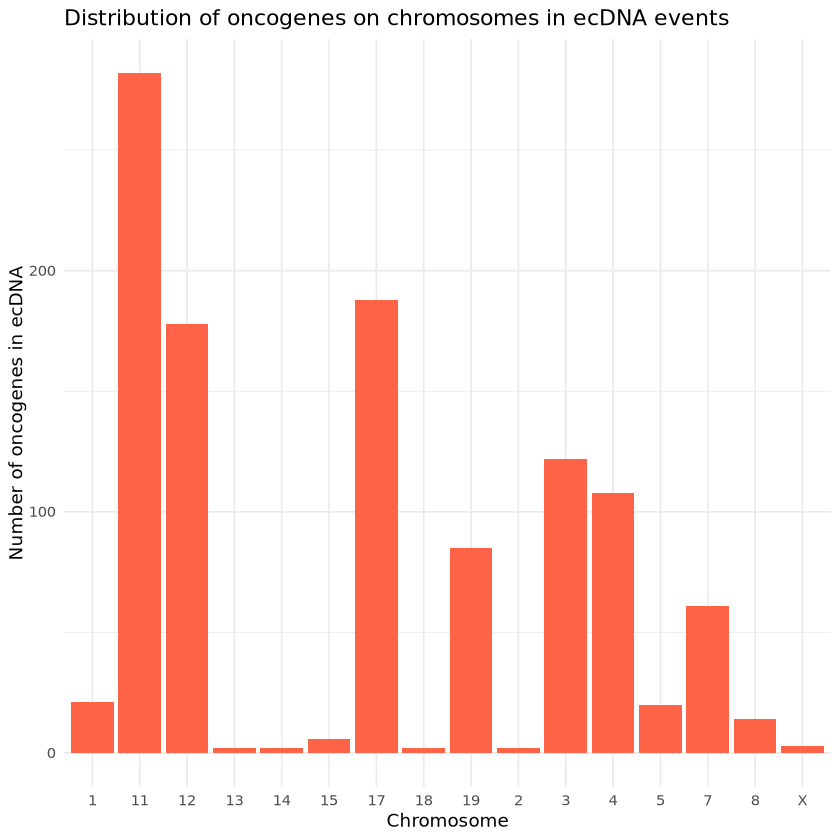

In [13]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)

# ---------------------------
# Extract chromosome (already done)
# ---------------------------
tcga_ecDNA <- tcga_ecDNA %>%
  mutate(chromosome = str_extract(location, "^[^:]+"))

# ---------------------------
# Clean and split oncogene column
# ---------------------------
tcga_ecDNA_onco <- tcga_ecDNA %>%
  # remove brackets and quotes from oncogenes
  mutate(oncogenes_clean = str_replace_all(oncogenes, "\\[|\\]|'|\"", ""),
         # split into list of oncogenes
         oncogenes_list = str_split(oncogenes_clean, ",\\s*")) %>%
  # expand so each oncogene is a separate row
  unnest(oncogenes_list)

# ---------------------------
# Count oncogenes per chromosome
# ---------------------------
onco_counts <- tcga_ecDNA_onco %>%
  group_by(chromosome) %>%
  summarise(num_oncogenes = n()) %>%
  arrange(factor(chromosome, levels = c(1:22, "X", "Y"))) # optional: order chromosomes

# ---------------------------
# Plot oncogenes per chromosome
# ---------------------------
ggplot(onco_counts, aes(x = chromosome, y = num_oncogenes)) +
  geom_bar(stat = "identity", fill = "tomato") +
  theme_minimal() +
  xlab("Chromosome") +
  ylab("Number of oncogenes in ecDNA") +
  ggtitle("Distribution of oncogenes on chromosomes in ecDNA events")


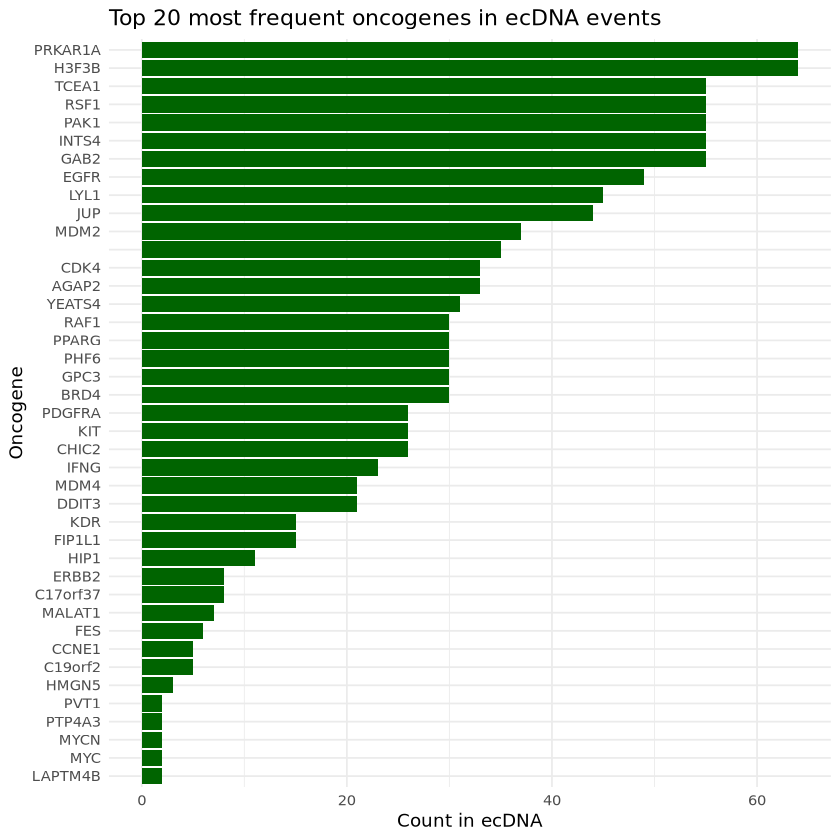

In [14]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)

# ---------------------------
# Clean and split oncogene column
# ---------------------------
tcga_ecDNA_onco <- tcga_ecDNA %>%
  mutate(oncogenes_clean = str_replace_all(oncogenes, "\\[|\\]|'|\"", ""),
         oncogenes_list = str_split(oncogenes_clean, ",\\s*")) %>%
  unnest(oncogenes_list)

# ---------------------------
# Count oncogenes per chromosome (as before)
# ---------------------------
onco_counts_chr <- tcga_ecDNA_onco %>%
  group_by(chromosome) %>%
  summarise(num_oncogenes = n()) %>%
  arrange(factor(chromosome, levels = c(1:22, "X", "Y")))

# ---------------------------
# Count most common oncogenes
# ---------------------------
top_oncogenes <- tcga_ecDNA_onco %>%
  group_by(oncogenes_list) %>%
  summarise(count = n()) %>%
  arrange(desc(count)) %>%
  slice_head(n = 50)  # top 20 most frequent oncogenes

# ---------------------------
# Plot most common oncogenes
# ---------------------------
ggplot(top_oncogenes, aes(x = reorder(oncogenes_list, count), y = count)) +
  geom_bar(stat = "identity", fill = "darkgreen") +
  coord_flip() +  # horizontal bars
  theme_minimal() +
  xlab("Oncogene") +
  ylab("Count in ecDNA") +
  ggtitle("Top 20 most frequent oncogenes in ecDNA events")


In [15]:
top_oncogenes

oncogenes_list,count
<chr>,<int>
H3F3B,64
PRKAR1A,64
GAB2,55
INTS4,55
PAK1,55
RSF1,55
TCEA1,55
EGFR,49
LYL1,45


In [16]:
colnames(tcga_ecDNA)


[1] "sample_name"     "location"        "classification"  "oncogenes"      
[5] "all_genes"       "chromosome"      "all_genes_clean" "all_genes_list"


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




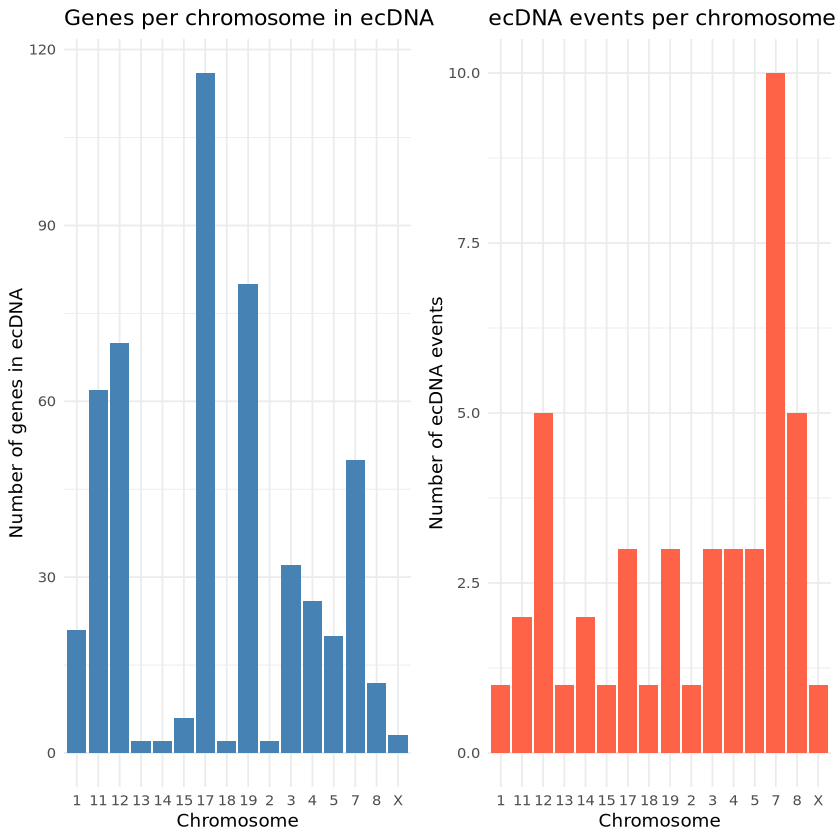

In [17]:
# ---------------------------
# 1. Count genes per chromosome
# ---------------------------
gene_counts <- tcga_ecDNA %>%
  unnest(all_genes_list) %>%           # each gene per row
  group_by(chromosome) %>%
  summarise(num_genes = n()) %>%
  arrange(factor(chromosome, levels = c(1:22, "X", "Y")))

# Plot genes per chromosome
p1 <- ggplot(gene_counts, aes(x = chromosome, y = num_genes)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  theme_minimal() +
  xlab("Chromosome") +
  ylab("Number of genes in ecDNA") +
  ggtitle("Genes per chromosome in ecDNA")

# ---------------------------
# 2. Count ecDNA events per chromosome
# ---------------------------
ecDNA_counts <- tcga_ecDNA %>%
  group_by(chromosome) %>%
  summarise(num_ecDNA = n_distinct(location)) %>%
  arrange(factor(chromosome, levels = c(1:22, "X", "Y")))

# Plot ecDNA events per chromosome
p2 <- ggplot(ecDNA_counts, aes(x = chromosome, y = num_ecDNA)) +
  geom_bar(stat = "identity", fill = "tomato") +
  theme_minimal() +
  xlab("Chromosome") +
  ylab("Number of ecDNA events") +
  ggtitle("ecDNA events per chromosome")

# ---------------------------
# 3. Optional: display plots side by side
# ---------------------------
library(gridExtra)
grid.arrange(p1, p2, ncol = 2)

In [18]:


# Example for genes per chromosome
gene_counts <- tcga_ecDNA %>%
  unnest(all_genes_list) %>%
  group_by(chromosome) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes))

# Get top 5
top5_genes <- gene_counts %>% slice(1:5)

# Sum all others
other_genes <- gene_counts %>% slice(6:n()) %>% summarise(chromosome = "Other", num_genes = sum(num_genes))

# Combine
gene_counts_top5 <- bind_rows(top5_genes, other_genes) %>%
  mutate(
    percentage = num_genes / sum(num_genes) * 100,
    label = paste0(chromosome, " (", round(percentage, 1), "%)")
  )


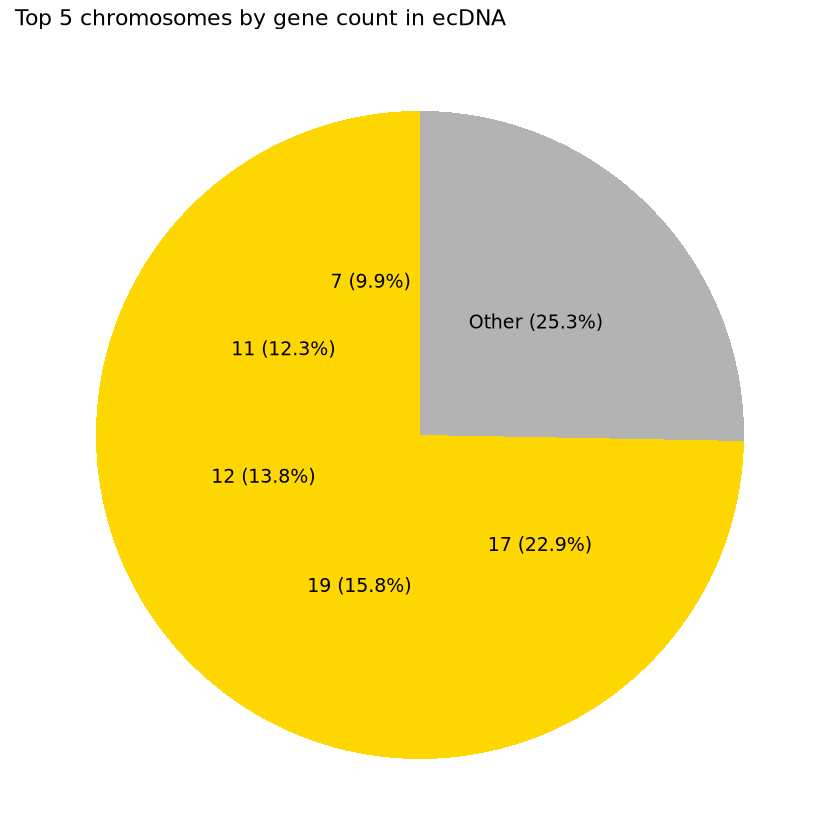

In [19]:
# Define colors: top5 = gold, others = grey
gene_counts_top5$fill_color <- ifelse(gene_counts_top5$chromosome == "Other", "grey70", "gold")

ggplot(gene_counts_top5, aes(x = "", y = num_genes, fill = fill_color)) +
  geom_bar(width = 1, stat = "identity") +
  coord_polar("y") +
  theme_void() +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5), size = 4) +
  scale_fill_identity() +
  ggtitle("Top 5 chromosomes by gene count in ecDNA")


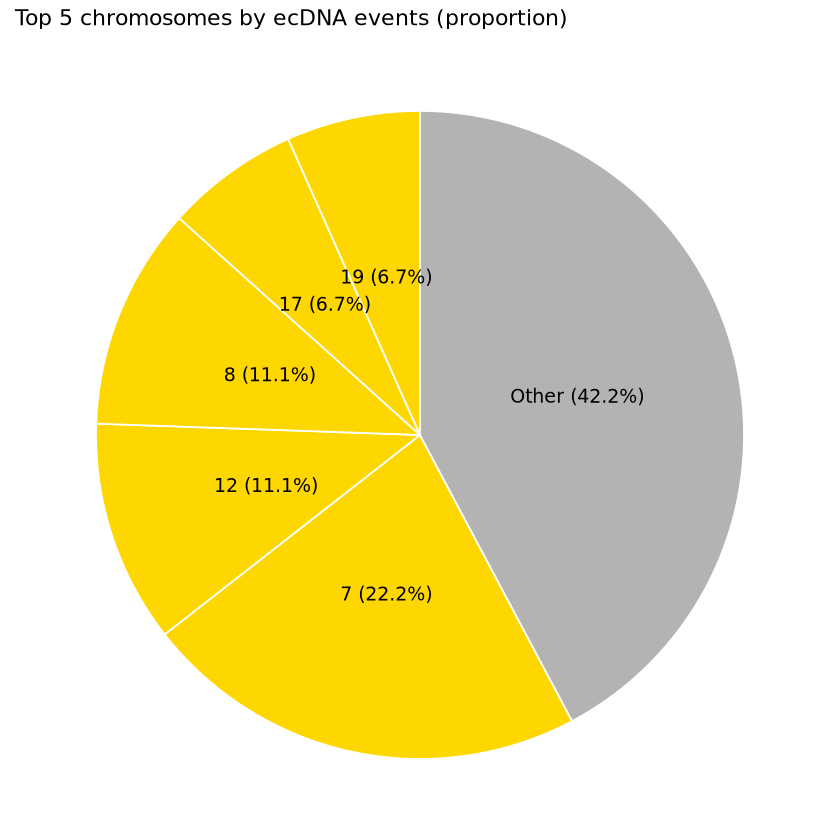

In [20]:
library(dplyr)
library(ggplot2)
library(scales)

# ------------------------------
# Count ecDNA events per chromosome
# ------------------------------
ecDNA_counts <- tcga_ecDNA %>%
  # merge p/q if present
  mutate(chromosome = sub("^(chr[0-9XY]+)[pq]?$", "\\1", chromosome)) %>%
  group_by(chromosome) %>%
  summarise(num_ecDNA = n_distinct(location)) %>%
  arrange(desc(num_ecDNA))

# ------------------------------
# Top 5 + Others
# ------------------------------
top5_events <- ecDNA_counts %>% slice(1:5)
other_events <- ecDNA_counts %>% slice(6:n()) %>% summarise(chromosome = "Other", num_ecDNA = sum(num_ecDNA))
ecDNA_counts_top5 <- bind_rows(top5_events, other_events) %>%
  mutate(
    percentage = num_ecDNA / sum(num_ecDNA) * 100,
    label = paste0(chromosome, " (", round(percentage, 1), "%)"),
    fill_color = ifelse(chromosome == "Other", "grey70", "gold")
  )

# ------------------------------
# 2️⃣ Proportion pie chart
# ------------------------------
p_pie <- ggplot(ecDNA_counts_top5, aes(x = "", y = percentage, fill = fill_color)) +
  geom_col(color = "white", width = 1) +
  coord_polar(theta = "y") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5), size = 4) +
  scale_fill_identity() +
  theme_void() +
  ggtitle("Top 5 chromosomes by ecDNA events (proportion)")

p_pie

In [32]:
tel_data <- read.delim("/home/mjehangir/telomere-sv-analysis/data/GLASS_subtypes_sv_tel_summary.csv", header = TRUE, sep = ",")

In [33]:
head(tel_data)

,patient_id,SV_type.x,SV_count,Total_width,telomere_diff,nlen,tlen,SV_density,SV_proportion,category.x,category.y
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,TCGA-02-2483,BND,115,8429,0.9864312,6.066187,5.079756,2.719032e-06,3.709677e-08,Non.codel,Non.codel
2,TCGA-02-2483,DEL,24,1877,0.9864312,6.066187,5.079756,6.054839e-07,7.741935e-09,Non.codel,Non.codel
3,TCGA-02-2483,DUP,34,4168,0.9864312,6.066187,5.079756,1.344516e-06,1.096774e-08,Non.codel,Non.codel
4,TCGA-02-2483,INV,3,29,0.9864312,6.066187,5.079756,9.354839e-09,9.677419e-10,Non.codel,Non.codel
5,TCGA-02-2485,BND,81,10069,-8.5896257,6.038091,14.627717,3.248065e-06,2.612903e-08,Non.codel,Non.codel
6,TCGA-02-2485,DEL,27,4874,-8.5896257,6.038091,14.627717,1.572258e-06,8.709677e-09,Non.codel,Non.codel


In [34]:
# ----------------------------
# 1. Extract clean TCGA ID
# ----------------------------
tel_data <- tel_data %>%
  mutate(TCGA_ID = str_sub(patient_id, 1, 12))   # TCGA-XX-XXXX

tcga_ecDNA <- tcga_ecDNA %>%
  mutate(TCGA_ID = str_sub(sample_name, 1, 12))

# ----------------------------
# 2. Merge datasets
# ----------------------------
merged_data <- tel_data %>%
  left_join(tcga_ecDNA, by = "TCGA_ID")

# ----------------------------
# 3. Check result
# ----------------------------
glimpse(merged_data)
head(merged_data)

Warning message in left_join(., tcga_ecDNA, by = "TCGA_ID"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 11 of `x` matches multiple rows in `y`.
ℹ Row 360 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


Rows: 1,325
Columns: 21
$ patient_id      <chr> "TCGA-02-2483", "TCGA-02-2483", "TCGA-02-2483", "TCGA-…
$ SV_type.x       <chr> "BND", "DEL", "DUP", "INV", "BND", "DEL", "DUP", "BND"…
$ SV_count        <int> 115, 24, 34, 3, 81, 27, 27, 18, 21, 13, 114, 114, 34, …
$ Total_width     <int> 8429, 1877, 4168, 29, 10069, 4874, 4787, 1878, 2426, 1…
$ telomere_diff   <dbl> 0.9864312, 0.9864312, 0.9864312, 0.9864312, -8.5896257…
$ nlen            <dbl> 6.066187, 6.066187, 6.066187, 6.066187, 6.038091, 6.03…
$ tlen            <dbl> 5.079756, 5.079756, 5.079756, 5.079756, 14.627717, 14.…
$ SV_density      <dbl> 2.719032e-06, 6.054839e-07, 1.344516e-06, 9.354839e-09…
$ SV_proportion   <dbl> 3.709677e-08, 7.741935e-09, 1.096774e-08, 9.677419e-10…
$ category.x      <chr> "Non.codel", "Non.codel", "Non.codel", "Non.codel", "N…
$ category.y      <chr> "Non.codel", "Non.codel", "Non.codel", "Non.codel", "N…
$ TCGA_ID         <chr> "TCGA-02-2483", "TCGA-02-2483", "TCGA-02-2483", "TCGA-…
$ sample_name   

,patient_id,SV_type.x,SV_count,Total_width,telomere_diff,nlen,tlen,SV_density,SV_proportion,category.x,⋯,TCGA_ID,sample_name,location,classification,oncogenes,all_genes,chromosome,all_genes_clean,all_genes_list,tcga_id
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,TCGA-02-2483,BND,115,8429,0.9864312,6.066187,5.079756,2.719032e-06,3.709677e-08,Non.codel,⋯,TCGA-02-2483,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,TCGA-02-2483,DEL,24,1877,0.9864312,6.066187,5.079756,6.054839e-07,7.741935e-09,Non.codel,⋯,TCGA-02-2483,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,TCGA-02-2483,DUP,34,4168,0.9864312,6.066187,5.079756,1.344516e-06,1.096774e-08,Non.codel,⋯,TCGA-02-2483,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,TCGA-02-2483,INV,3,29,0.9864312,6.066187,5.079756,9.354839e-09,9.677419e-10,Non.codel,⋯,TCGA-02-2483,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,TCGA-02-2485,BND,81,10069,-8.5896257,6.038091,14.627717,3.248065e-06,2.612903e-08,Non.codel,⋯,TCGA-02-2485,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,TCGA-02-2485,DEL,27,4874,-8.5896257,6.038091,14.627717,1.572258e-06,8.709677e-09,Non.codel,⋯,TCGA-02-2485,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [35]:
nrow(merged_data)

[1] 1325

In [36]:
library(dplyr)
library(stringr)

# Make sure IDs are comparable (first 12 chars)
tel_data <- tel_data %>%
  mutate(TCGA_ID = str_sub(patient_id, 1, 12))

tcga_ecDNA <- tcga_ecDNA %>%
  mutate(TCGA_ID = str_sub(sample_name, 1, 12))

# Check overlap
length(unique(tel_data$TCGA_ID))
length(unique(tcga_ecDNA$TCGA_ID))

# How many match?
length(intersect(tel_data$TCGA_ID, tcga_ecDNA$TCGA_ID))

# Show examples that don’t match
setdiff(tel_data$TCGA_ID, tcga_ecDNA$TCGA_ID)[1:20]


[1] 137

[1] 25

[1] 14

[1] "TCGA-02-2483" "TCGA-02-2485" "TCGA-06-0124" "TCGA-06-0145" "TCGA-06-0155"
 [6] "TCGA-06-0157" "TCGA-06-0171" "TCGA-06-0190" "TCGA-06-0214" "TCGA-06-0648"
[11] "TCGA-06-0686" "TCGA-06-0744" "TCGA-06-0745" "TCGA-06-0881" "TCGA-06-1086"
[16] "TCGA-06-2557" "TCGA-06-2570" "TCGA-06-5411" "TCGA-06-5415" "TCGA-14-0786"

In [37]:
merged_data <- tel_data %>%
  inner_join(
    tcga_ecDNA %>%
      select(TCGA_ID, sample_name, location, classification, oncogenes, all_genes),
    by = "TCGA_ID"
  )

# check how many rows now
nrow(merged_data)
dplyr::distinct(merged_data, TCGA_ID) %>% nrow()
head(merged_data, 10)


Warning message in inner_join(., tcga_ecDNA %>% select(TCGA_ID, sample_name, location, :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 11 of `x` matches multiple rows in `y`.
ℹ Row 360 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


[1] 725

[1] 14

,patient_id,SV_type.x,SV_count,Total_width,telomere_diff,nlen,tlen,SV_density,SV_proportion,category.x,category.y,TCGA_ID,sample_name,location,classification,oncogenes,all_genes
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,TCGA-06-0125,BND,114,9222,3.749429,6.473299,2.723869,2.974839e-06,3.677419e-08,Non.codel,Non.codel,TCGA-06-0125,TCGA-06-0125-01A-01D-1490-08_MN_10A-01D-1490,7:54757847-55383834,ecDNA,EGFR,"EGFR, SEC61G"
2,TCGA-06-0125,BND,114,9222,3.749429,6.473299,2.723869,2.974839e-06,3.677419e-08,Non.codel,Non.codel,TCGA-06-0125,TCGA-06-0125-01A-01D-1490-08_MN_10A-01D-1490,7:54757847-55383834,ecDNA,EGFR,"EGFR, SEC61G"
3,TCGA-06-0125,DEL,34,2140,3.749429,6.473299,2.723869,6.903226e-07,1.096774e-08,Non.codel,Non.codel,TCGA-06-0125,TCGA-06-0125-01A-01D-1490-08_MN_10A-01D-1490,7:54757847-55383834,ecDNA,EGFR,"EGFR, SEC61G"
4,TCGA-06-0125,DEL,34,2140,3.749429,6.473299,2.723869,6.903226e-07,1.096774e-08,Non.codel,Non.codel,TCGA-06-0125,TCGA-06-0125-01A-01D-1490-08_MN_10A-01D-1490,7:54757847-55383834,ecDNA,EGFR,"EGFR, SEC61G"
5,TCGA-06-0125,DUP,49,5832,3.749429,6.473299,2.723869,1.881290e-06,1.580645e-08,Non.codel,Non.codel,TCGA-06-0125,TCGA-06-0125-01A-01D-1490-08_MN_10A-01D-1490,7:54757847-55383834,ecDNA,EGFR,"EGFR, SEC61G"
6,TCGA-06-0125,DUP,49,5832,3.749429,6.473299,2.723869,1.881290e-06,1.580645e-08,Non.codel,Non.codel,TCGA-06-0125,TCGA-06-0125-01A-01D-1490-08_MN_10A-01D-1490,7:54757847-55383834,ecDNA,EGFR,"EGFR, SEC61G"
7,TCGA-06-0128,BND,17,1639,4.950833,7.624396,2.673563,5.287097e-07,5.483871e-09,Non.codel,Non.codel,TCGA-06-0128,TCGA-06-0128-01A-01D-0572-09_MN_10A-01D-0572,12:58074283-58629028,ecDNA,"AGAP2, CDK4","AGAP2, AVIL, CDK4, CTDSP2, CYP27B1, FAM119B, MARCH9, METTL1, OS9, TSFM, TSPAN31, XRCC6BP1"
8,TCGA-06-0128,BND,17,1639,4.950833,7.624396,2.673563,5.287097e-07,5.483871e-09,Non.codel,Non.codel,TCGA-06-0128,TCGA-06-0128-01A-01D-0572-09_MN_10A-01D-0572,12:58074283-58629028,ecDNA,"AGAP2, CDK4","AGAP2, AVIL, CDK4, CTDSP2, CYP27B1, FAM119B, MARCH9, METTL1, OS9, TSFM, TSPAN31, XRCC6BP1"
9,TCGA-06-0128,BND,17,1639,4.950833,7.624396,2.673563,5.287097e-07,5.483871e-09,Non.codel,Non.codel,TCGA-06-0128,TCGA-06-0128-01A-01D-0572-09_MN_10A-01D-0572,12:58074283-58629028,ecDNA,"AGAP2, CDK4","AGAP2, AVIL, CDK4, CTDSP2, CYP27B1, FAM119B, MARCH9, METTL1, OS9, TSFM, TSPAN31, XRCC6BP1"


In [38]:

unique(merged_data$category.x)
table(merged_data$category.x)


[1] "Non.codel" "WT"


Non.codel        WT 
      579       146 

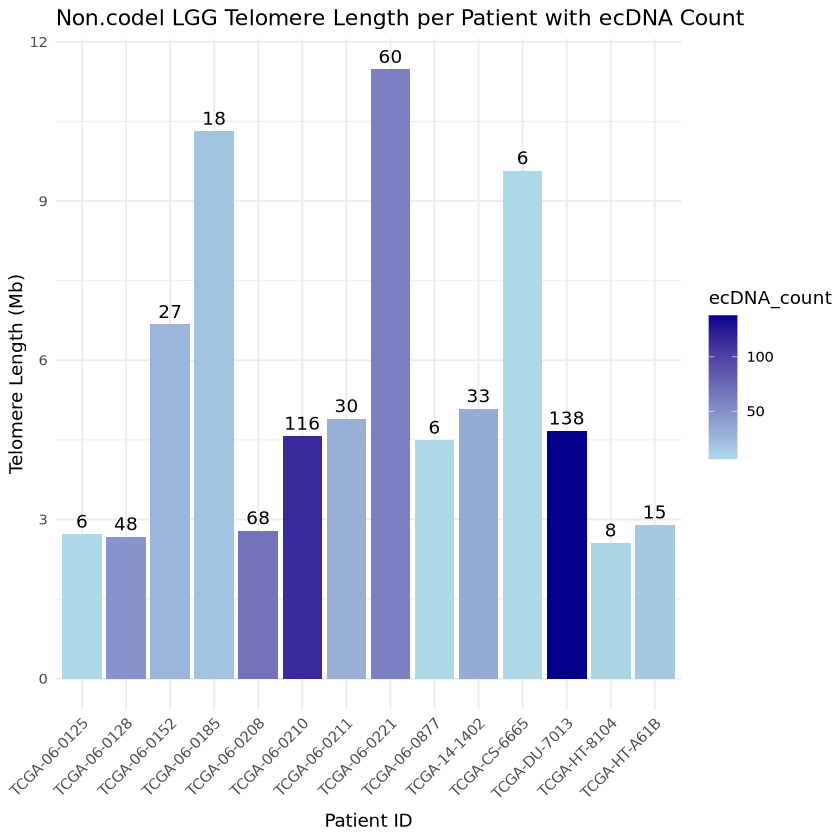

In [48]:
library(ggplot2)
library(dplyr)

# Keep only Non.codel patients
noncodel_data <- merged_data %>%
  filter(category.x == "Non.codel")

# Summarize telomere length and ecDNA count per patient
tel_summary <- noncodel_data %>%
  group_by(patient_id) %>%
  summarise(
    tlen = mean(tlen, na.rm = TRUE),                    # average telomere length
    ecDNA_count = sum(classification == "ecDNA", na.rm = TRUE),
    .groups = "drop"
  )

# -----------------------------
# Plot telomere length with ecDNA count
# -----------------------------
ggplot(tel_summary, aes(x = patient_id, y = tlen, fill = ecDNA_count)) +
  geom_col() +                                           # telomere length as bar
  geom_text(aes(label = ecDNA_count), vjust = -0.5) +   # show ecDNA count above bar
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  theme_minimal() +
  xlab("Patient ID") +
  ylab("Telomere Length (Mb)") +
  ggtitle("Non.codel LGG Telomere Length per Patient with ecDNA Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


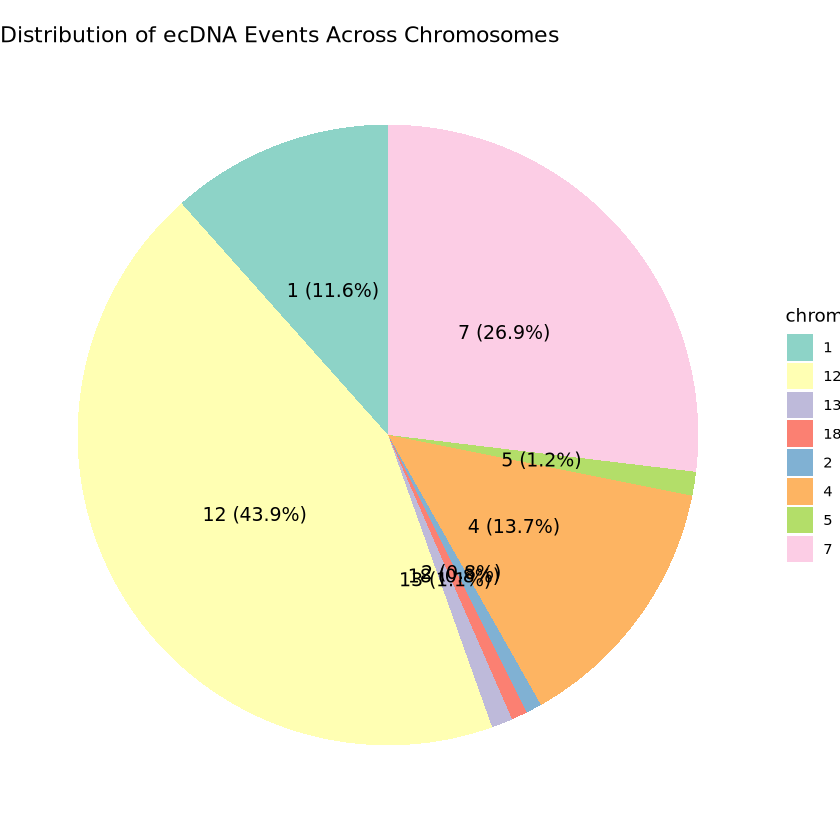

In [55]:
library(ggplot2)
library(dplyr)

# Keep only ecDNA rows
ecDNA_data <- merged_data %>%
  filter(classification == "ecDNA")

# Extract chromosome from location (format: "7:54757847-55383834")
ecDNA_data <- ecDNA_data %>%
  mutate(chrom = sub(":.*", "", location))

# Count ecDNA per chromosome
chrom_count <- ecDNA_data %>%
  group_by(chrom) %>%
  summarise(count = n(), .groups = "drop") %>%
  arrange(desc(count))

# Compute percentages for labels
chrom_count <- chrom_count %>%
  mutate(pct = round(count / sum(count) * 100, 1),
         label = paste0(chrom, " (", pct, "%)"))

# -----------------------------
# Pie chart
# -----------------------------
ggplot(chrom_count, aes(x = "", y = count, fill = chrom)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar(theta = "y") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5), size = 4) +
  theme_void() +
  labs(title = "Distribution of ecDNA Events Across Chromosomes") +
  scale_fill_brewer(palette = "Set3")

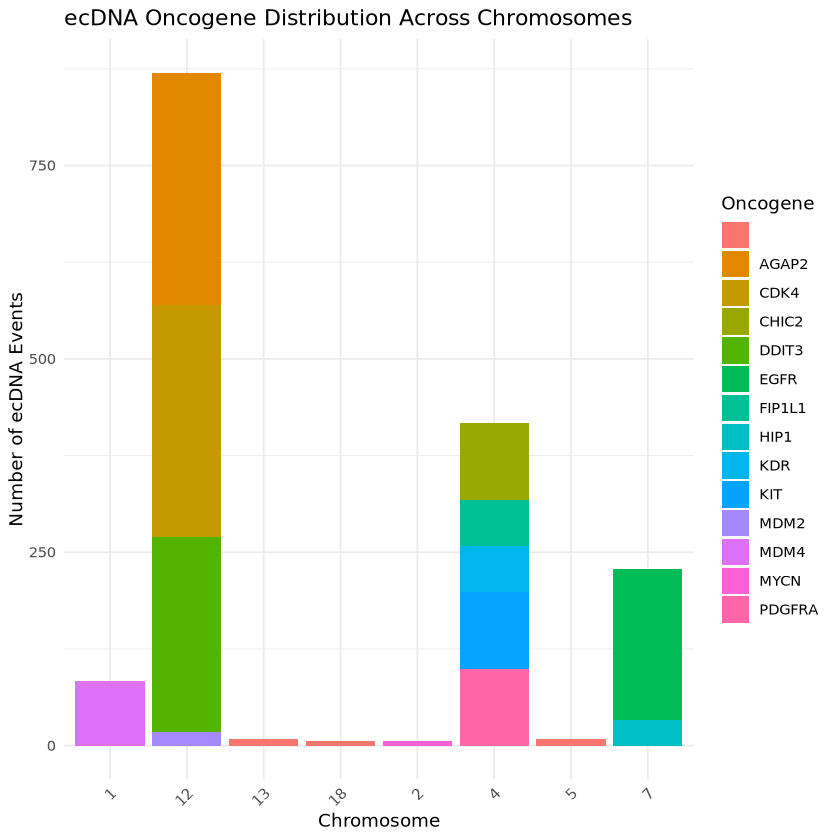

In [58]:
# Keep only ecDNA rows
ecDNA_data <- merged_data %>%
  filter(classification == "ecDNA") %>%
  mutate(chrom = sub(":.*", "", location))

# Split multiple oncogenes per row
ecDNA_onco <- ecDNA_data %>%
  separate_rows(oncogenes, sep = ",\\s*")

# Count number of ecDNA events per oncogene per chromosome
oncogene_count <- ecDNA_onco %>%
  group_by(chrom, oncogenes) %>%
  summarise(count = n(), .groups = "drop") %>%
  arrange(chrom, desc(count))

# Optional: keep top N oncogenes overall for clarity
top_oncogenes <- oncogene_count %>%
  group_by(oncogenes) %>%
  summarise(total_count = sum(count)) %>%
  top_n(20, total_count) %>%
  pull(oncogenes)

oncogene_count_filtered <- oncogene_count %>%
  filter(oncogenes %in% top_oncogenes)

# -----------------------------
# Stacked bar plot: chromosome vs oncogenes
# -----------------------------
ggplot(oncogene_count_filtered, aes(x = chrom, y = count, fill = oncogenes)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "ecDNA Oncogene Distribution Across Chromosomes",
       x = "Chromosome",
       y = "Number of ecDNA Events",
       fill = "Oncogene") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))